In [39]:
# Install BioPython
!pip install --user biopython

In [40]:
from Bio import SeqIO
from Bio.Data import CodonTable
import pandas as pd

In [41]:
## 1 ##
### Use Docstring ''' '''
### def get_sequences_from_file(fasta_fn):"""[Explanation for this function]"""
    # code for getting sequences
    
def get_sequences_from_file(fasta_fn):
    """
    This function extract species names and genetic sequences from a FASTA file.

    Inputs:
        fasta_fn (string): This is a file path of the FASTA file.

    Outputs:
        sequence_data_dict: This is a dictionary where the strings show the species names 
        and the values are actual nucleotide sequences (Bio.Seq objects).
    """
    sequence_data_dict = {}
    # Use SeqIO to iterate through each record in the FASTA file
    for record in SeqIO.parse(fasta_fn, "fasta"):
        description = record.description.split()
        # Extracts genus (index 1) and species (index 2) to create a full name
        species_name = description[1] + " " + description[2]
        sequence_data_dict[species_name] = record.seq
    return(sequence_data_dict)


                

In [42]:
## 2 ##
### Use Docstring
### translate_function(string_list):"""[Explanation for THIS function goes here]"""
    # code for translating DNA to protein

from Bio.Data import CodonTable

def translate_function(string_nucleotides):
    """
    Translate function is to translate a DNA seq into an amino acid seq using a loop.
    
    This function processes DNA in groups of three (codons) and maps them 
    to amino acids.
    
    Inputs:
        string_nucleotides: The DNA sequence to be translated.
        
    Outputs:
        str: The amino acid sequence string.
    """
    # 1. Load the codon table
    mito_table = CodonTable.unambiguous_dna_by_name["Vertebrate Mitochondrial"]
    
    aa_seq_string = ""
    
    # 2. Loop through the string
    # range(start, stop, step)
        # The "0" tells to start at the very first nucleotide (position 1)
        # len(string_nucleotides) tells the loop keep going until it reaches the end of string
    for i in range(0, len(string_nucleotides), 3):
        # loop through every 3rd position mimicing ribosome reads three bases (codon)
        codon = string_nucleotides[i:i+3] 
        
        # 3. Stop codon checking
        # Stop if it hits a stop codon or if the remaining sequence is less than 3 bases
        if codon in mito_table.stop_codons or len(codon) < 3:
            break # Exits the loop without adding (ignore stop codons at the end)
            
        # 4. Retrieve amino acids
        # look up the dictionary of represents of protein letters
        aa = mito_table.forward_table[codon] 
        # Add it to strings
        aa_seq_string += aa 
        
    return aa_seq_string



In [43]:
## 3 ##

### Alternative functions: .translate()

def alternative_translate_function(string_nucleotides):
    """
    This translates a DNA seq to an amino acid using Biopython's built-in translate method.
    
    Inputs:
        string_nucleotides: The DNA sequence to be translated.

    Outputs:
        str: The translated amino acid.
    """
    # Use the .translate()
    # to_stop=True makes to stop at the first stop codon and doesn't include it (ignore stop codons at the end)
    aa_seq = string_nucleotides.translate(table="Vertebrate Mitochondrial", to_stop=True)
    
    return str(aa_seq)



In [44]:
## 4 ##

### Use ProteinAnalysis from ProtParam module
from Bio.SeqUtils.ProtParam import ProteinAnalysis

### Count AA analysis function
def compute_molecular_weight(aa_seq):
    """
    This calculates the molecular weight of an amino acid sequence.
    
    This uses Biopython's ProteinAnalysis module. It requires 
    the input to be a string, no stop codons or gaps.

    Inputs:
        aa_seq: A string of amino acids.

    Outputs:
        float: The calculated molecular weight of the protein.
    """ 
    # Ensure a string and not stop codons (*)
    aa_seq_str = str(aa_seq).replace("*", "")
    
    # Initialize the analysis
    analysed_seq = ProteinAnalysis(aa_seq_str)
    
    # Return the molecular weight
    return analysed_seq.molecular_weight()


In [45]:
## 5 ##
### Use gc_fraction to calculate the GC content
from Bio.SeqUtils import gc_fraction

### GC content analysis function

def calculate_gc_content(dna_seq):
    """
    This calculates the GC-content of a DNA sequence.

    Inputs:
        dna_seq: The DNA sequence to analyze.

    Outputs:
        float: The GC-content as a decimal (0-1).
    """
    return gc_fraction(dna_seq)


#%%%%%%%%%%%%%%#
###   MAIN   ###
#%%%%%%%%%%%%%%#

# Load the sequence data into a dictionary
# Keys are species names, values are the DNA sequences
cytb_seqs = get_sequences_from_file("penguins_cytb.fasta") 

# Load the mass data into a Pandas DataFrame
penguins_df = pd.read_csv("penguins_mass.csv") 

# Create a list of species names from the DataFrame for easy iteration
species_list = list(penguins_df.species)


In [46]:
## 6 ## 

# Add the new columns and set the value to NaN (empty/null)
penguins_df['molecular_weight'] = None
penguins_df['GC_content'] = None


In [47]:
## 7 ##

# Iterate through the dictionary of sequences
# Key is species_name and value is dna_sequence
for species_name, dna_sequence in cytb_seqs.items():
    
    # Translate the DNA sequence to Amino Acids
    aa_seq = alternative_translate_function(dna_sequence)
    
    # Compute molecular weight
    mol_weight = compute_molecular_weight(aa_seq)
    
    # Compute GC content
    gc_cont = calculate_gc_content(dna_sequence)
    
    # Fill in empty cells in the DataFrame
    # Use .loc to find the row where the 'species' column matches current species_name
    penguins_df.loc[penguins_df['species'] == species_name, 'molecular_weight'] = mol_weight
    penguins_df.loc[penguins_df['species'] == species_name, 'GC_content'] = gc_cont


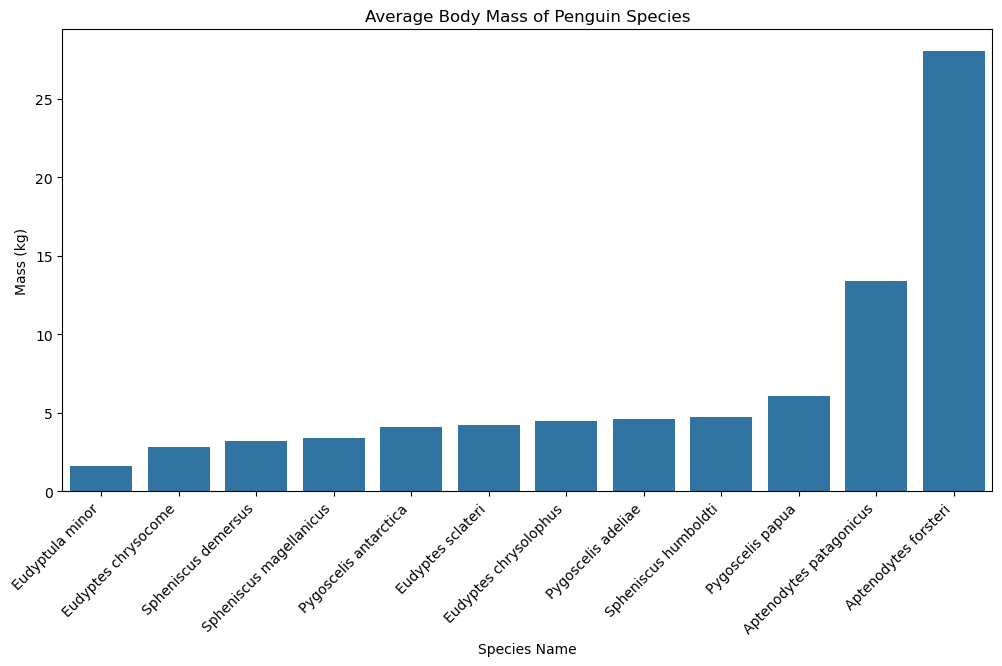

In [48]:
## 8 ##

import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size
plt.figure(figsize=(12, 6))

# Create a bar chart
# Sort by mass so the smallest penguin appears first
ax = sns.barplot(x='species', y='mass', data=penguins_df.sort_values('mass'))

# Labeling axes and title and Formatting
plt.title('Average Body Mass of Penguin Species')
plt.xlabel('Species Name')
plt.ylabel('Mass (kg)')
plt.xticks(rotation=45, ha='right')

plt.show()

### Answers
## Q1: The smallest penguin species is Eudyptula minor
## Q2: They live the coasts of southern Australia and New Zealand

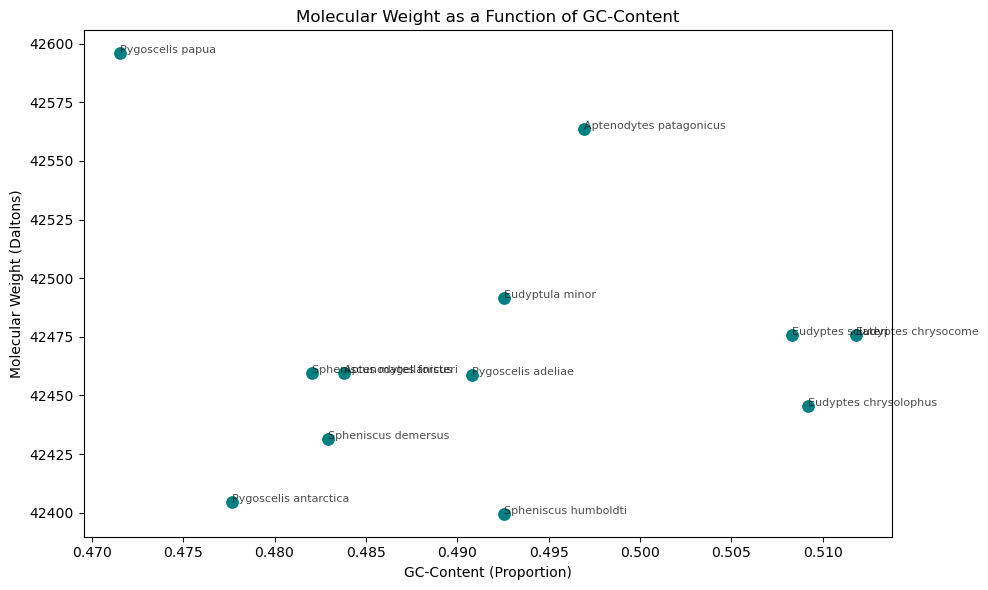

In [49]:
## 9 ##

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Create a scatter plot
sns.scatterplot(x='GC_content', y='molecular_weight', data=penguins_df, s=100, color='teal')

# Labeling
plt.title('Molecular Weight as a Function of GC-Content')
plt.xlabel('GC-Content (Proportion)')
plt.ylabel('Molecular Weight (Daltons)')

# Labeling data on the plot
for i in range(penguins_df.shape[0]):
    # Only label if there is valid data to prevent errors
    if not pd.isna(penguins_df.GC_content[i]):
        plt.text(penguins_df.GC_content[i], 
                 penguins_df.molecular_weight[i], 
                 penguins_df.species[i], 
                 fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

In [50]:
## 10 ##

# Save the updated DataFrame
# index=False ensures that the row numbers (0, 1, 2...) aren't saved as a separate column
penguins_df.to_csv("penguins_mass_cytb.csv", index=False)

print("File 'penguins_mass_cytb.csv' has been successfully saved to your directory.")

File 'penguins_mass_cytb.csv' has been successfully saved to your directory.


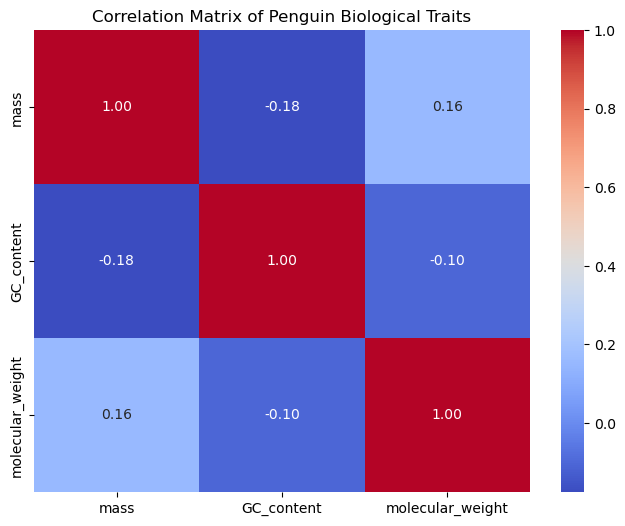

In [51]:
## 11 ##
## Correlation Heatmap ##

plt.figure(figsize=(8, 6))

# Calculate the correlation matrix for numeric columns
# Filter for only the columns we want to compare
corr = penguins_df[['mass', 'GC_content', 'molecular_weight']].corr()

# Plot the heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlation Matrix of Penguin Biological Traits')
plt.show()